In [1]:
from google.colab import files
uploaded = files.upload()


Saving Train.csv to Train.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("Train.csv")
print("Dataset Size:", df.shape)
df.head()


Dataset Size: (10999, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [4]:
np.random.seed(10)

df['Delivery_Day'] = np.random.randint(1, 8, df.shape[0])

df[['Delivery_Day']].head()

,Delivery_Day
0,2
1,6
2,5
3,1
4,2


In [5]:
df['Day_sin'] = np.sin(2 * np.pi * df['Delivery_Day'] / 7)
df['Day_cos'] = np.cos(2 * np.pi * df['Delivery_Day'] / 7)

df[['Delivery_Day', 'Day_sin', 'Day_cos']].head()

,Delivery_Day,Day_sin,Day_cos
0,2,0.974928,-0.222521
1,6,-0.781831,0.623490
2,5,-0.974928,-0.222521
3,1,0.781831,0.623490
4,2,0.974928,-0.222521


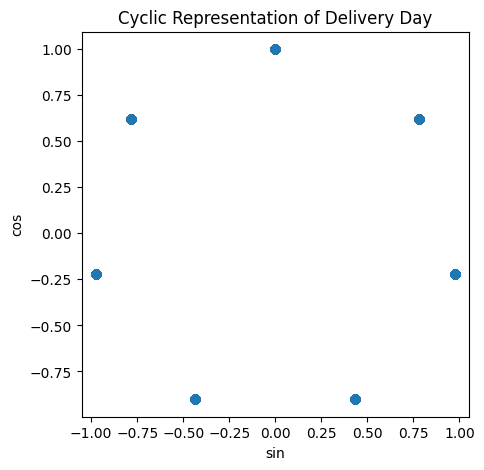

In [6]:
plt.figure(figsize=(5,5))
plt.scatter(df['Day_sin'], df['Day_cos'], alpha=0.4)
plt.title("Cyclic Representation of Delivery Day")
plt.xlabel("sin")
plt.ylabel("cos")
plt.axis("equal")
plt.show()

In [7]:
cost_equal_bins = pd.cut(
    df['Cost_of_the_Product'],
    bins=5    # different bin count
)

df['Cost_Level_Equal'] = cost_equal_bins

df[['Cost_of_the_Product', 'Cost_Level_Equal']].head()

,Cost_of_the_Product,Cost_Level_Equal
0,177,"(138.8, 181.6]"
1,216,"(181.6, 224.4]"
2,183,"(181.6, 224.4]"
3,176,"(138.8, 181.6]"
4,184,"(181.6, 224.4]"


In [8]:
cost_quantile_bins = pd.qcut(
    df['Cost_of_the_Product'],
    q=5
)

df['Cost_Level_Quantile'] = cost_quantile_bins

df[['Cost_of_the_Product', 'Cost_Level_Quantile']].head()

,Cost_of_the_Product,Cost_Level_Quantile
0,177,"(161.0, 196.0]"
1,216,"(196.0, 231.0]"
2,183,"(161.0, 196.0]"
3,176,"(161.0, 196.0]"
4,184,"(161.0, 196.0]"


In [9]:
from sklearn.preprocessing import KBinsDiscretizer

cost_discretizer = KBinsDiscretizer(
    n_bins=5,
    encode='ordinal',
    strategy='uniform'
)

cost_kbins = cost_discretizer.fit_transform(
    df[['Cost_of_the_Product']]
)

df['Cost_Level_KBins'] = cost_kbins.astype(int)

df[['Cost_of_the_Product', 'Cost_Level_KBins']].head()

,Cost_of_the_Product,Cost_Level_KBins
0,177,1
1,216,2
2,183,2
3,176,1
4,184,2


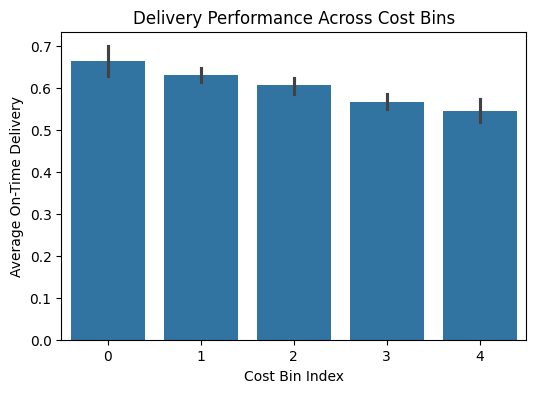

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.barplot(
    x='Cost_Level_KBins',
    y='Reached.on.Time_Y.N',
    data=df
)
plt.title("Delivery Performance Across Cost Bins")
plt.xlabel("Cost Bin Index")
plt.ylabel("Average On-Time Delivery")
plt.show()